In [1]:
import pytesseract
from PIL import Image
import cv2
import matplotlib.pyplot as plt

pytesseract.pytesseract.tesseract_cmd = r"c:\Users\dipes\Coding\python\OCR-python\tesseract\tesseract.exe"

In [ ]:
img = cv2.imread('test.jpg')
if img is None:
    raise FileNotFoundError("test.jpg not found")
# transforming to inverse binary
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, binary_img = cv2.threshold(img, 127, 255,cv2.THRESH_BINARY_INV)
# plotting the binary image
cv2.imwrite("binary.jpg", binary_img)

True

In [11]:
img_file = "inverted_image.jpg"
img = Image.open(img_file)
ocr_result = pytesseract.image_to_string(img)
print(ocr_result)

andi vhenfirent ders ATH, aes - 600036 Mobile: +919313396711 Blood Group:B +ve
(Aa faa sient Vem tare HIM, UT BSR) Ke

Indian Institute of Technology Madras, Chennai - 600036 ‘ X Residential Address:

(An Autonomous Institution under MHRD, GOI) O-23A Saurabh Vihar Jaitpur Badarpur New Delhi-44
New Delhi, Delhi-(National-Capital-Territory), India -
110044

DIPESH KUMAR Date of Birth:18-12-2005 |
Level: DIPLOMA L
ID Card Validity: JAN 2026 - DEC 2026
BS in Data Science and Applications ‘a
Roll No:24F3003248 Ber
BS Degree Office, 3rd Floor, . .
onl. ICSR Building, IIT Madras, https://study.iitm.ac.in/ds
f+ Chennai - 600036 7850-999966 (Mon-Fri 9am-6pm)

Card Holder Authorised! by



In [4]:
# img_file = "thick_font.jpg"
# img = Image.open(img_file)
# ocr_result = pytesseract.image_to_string(img)
# print(ocr_result)

## Row Wise Extraction in pytesseract

In [ ]:
image_path = "test.jpg"
image = cv2.imread(image_path)

In [ ]:
if image is None:
    raise FileNotFoundError("test.jpg not found")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [13]:
blur = cv2.GaussianBlur(gray, (7,7), 0)
cv2.imshow("Blur", blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

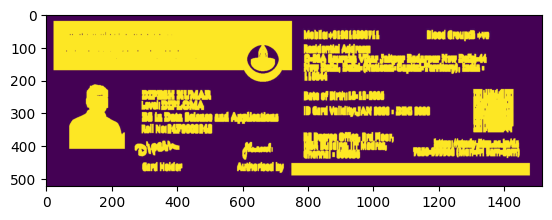

In [34]:
binary_img = cv2.imread("binary.jpg")
binary_img = cv2.cvtColor(binary_img, cv2.COLOR_BGR2GRAY)
iterations = 1
kernal = cv2.getStructuringElement(cv2.MORPH_RECT,(3, 13))
dilate = cv2.dilate(binary_img, kernal, iterations=iterations)
cv2.imwrite("index_dilate.png", dilate)
plt.imshow(dilate)

In [35]:
cnts = cv2.findContours(dilate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]

In [36]:
cnts = sorted(cnts, key=lambda x: cv2.boundingRect(x)[0])

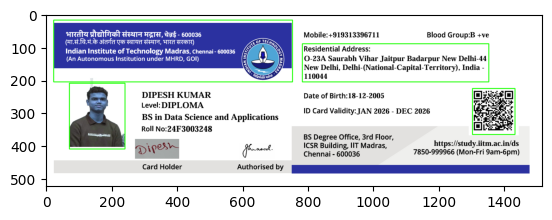

In [42]:
image_path = "test.jpg"
image = cv2.imread(image_path)
for c in cnts:
    x, y, w, h = cv2.boundingRect(c)
    if h > 100 and w > 20:
        cv2.rectangle(image, (x, y), (x+w, y+h), (36, 255, 12), 2)
plt.imshow(image)

## How to OCR a Text with Marginalia

## dealing with a specific section of an image 


import pytesseract
import cv2


image = cv2.imread('data/sample_mgh.jpg')
im_h, im_w, im_d = image.shape
base_image = image.copy()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7,7), 0)
thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Create rectangular structuring element and dilate
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (50,10))
dilate = cv2.dilate(thresh, kernel, iterations=1)

# Find contours and draw rectangle
cnts = cv2.findContours(dilate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
cnts = sorted(cnts, key=lambda x: cv2.boundingRect(x)[1])
for c in cnts:
    x,y,w,h = cv2.boundingRect(c)
    if h < 20 and w > 250:
        roi = base_image[0:y+h, 0:x+im_w]
        cv2.rectangle(image, (x, y), (x + w, y + h), (36,255,12), 2)
        
cv2.imwrite("temp/output.png", roi)